<a href="https://colab.research.google.com/github/mohd-Khan-01/LLM_from_Scratch/blob/main/Chapter4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Implementing a GPT model from scratch to generate text(Chapter 4)

Till now we have completed step 1 and step 2 of the stage 1 of coding an llm,

Now lets move onto the last step ,step 3 of the stage 1.

 :)


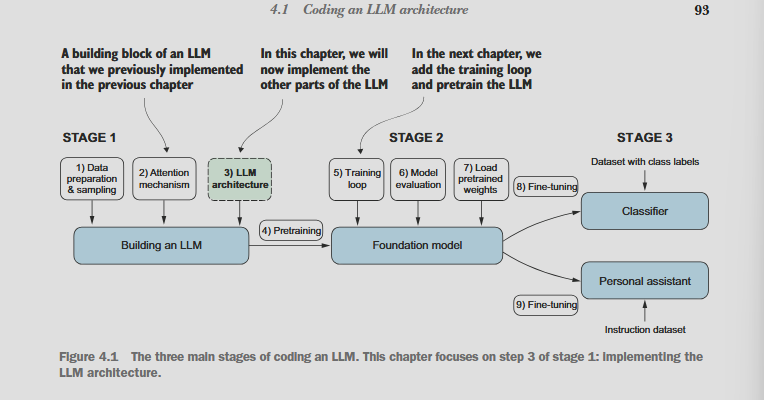

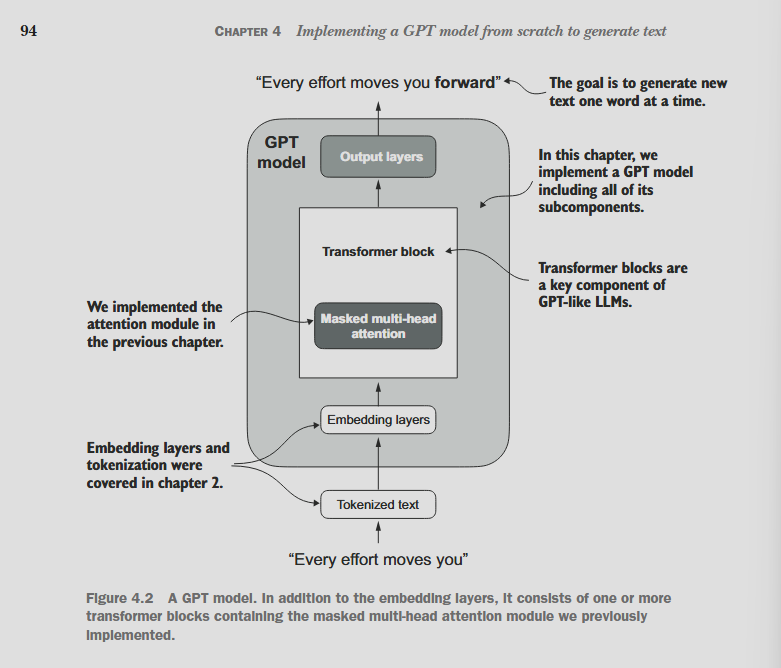

let us specify the configuratiio of the small GPT-2 model via the following dictionaries

In [2]:
GPT_CONFIG_124M={
    "vocab_size":50257,
    "context_length":1024,
    "emb_dim":768,
    "n_heads":12,
    "n_layers":12,
    "drop_rate":0.1,
    "qkv_bias":False
}

# In the GPT_CONFIG_124M dictionary, we use concise variable names for clarity and to


prevent long lines of code:


 vocab_size refers to a vocabulary of 50,257 words, as used by the BPE tokenizer
(see chapter 2).


 context_length denotes the maximum number of input tokens the model can
handle via the positional embeddings (see chapter 2).



 emb_dim represents the embedding size, transforming each token into a 768 dimensional vector.

 n_heads indicates the count of attention heads in the multi-head attention mechanism (see chapter 3).

 n_layers specifies the number of transformer blocks in the model, which we will cover in the upcoming discussion.

 drop_rate indicates the intensity of the dropout mechanism (0.1 implies a 10% random drop out of hidden units) to prevent overfitting (see chapter 3).

 qkv_bias determines whether to include a bias vector in the Linear layers of the multi-head attention for query, key, and value computations. We will initially disable this, following the norms of modern LLMs, but we will revisit it in chapter 6 when we load pretrained GPT-2 weights from OpenAI into our model (see chapter 6).

using the above configuration we are going to build an dummy model,
it will provide us with the big picture how everything fits together.
and what other components we need to code to assemble the full gpt model.

look at the figure below to understand it in more depth

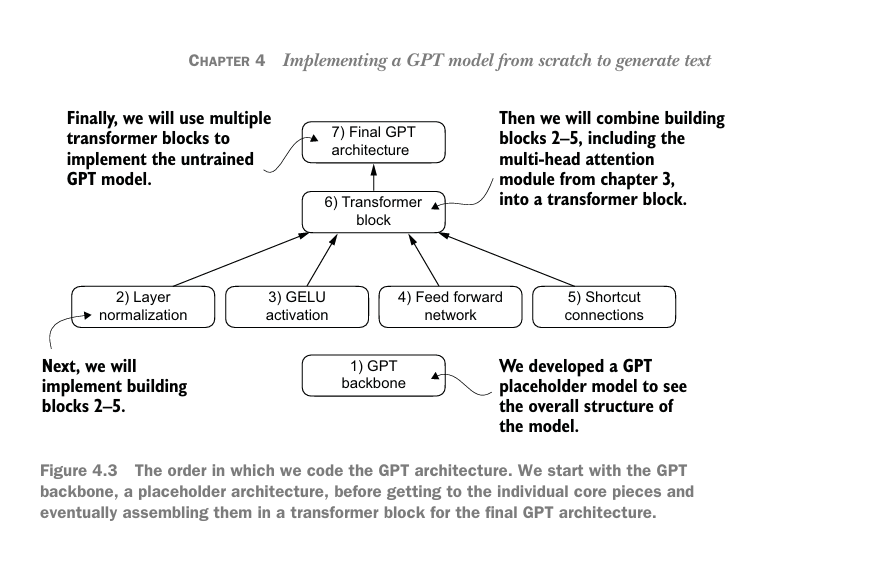

# A placeholder GPT model architecture class

In [3]:
import torch
import torch.nn as nn
class DummyGPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emd=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])
    self.trf_blocks=nn.Sequential(
        *[DummyTransformerBlock(cfg)
          for _ in range(cfg["n_layers"])]
)
    self.final_norm = DummyLayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
        cfg["emb_dim"] , cfg["vocab_size"],bias=False )

  def forward(self,in_idx):
    batch_size,seq_len=in_idx.shape
    tok_embeds=self.tok_emb(in_idx)
    pos_embeds=self.pos_emd(
        torch.arange(seq_len,device=in_idx.device)
    )

    x=tok_embeds + pos_embeds
    x=self.drop_emb(x)
    x=self.trf_blocks(x)
    x=self.final_norm(x)
    logits=self.out_head(x)
    return logits
class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
      super().__init__()

    def forward (self,x):
      return x
class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps=1e-5):
      super().__init__()
    def forward(self,x):
      return x

the DummyGPTModel class in this code defines a simplified version of a gpt-like structure using the neural network in the pytorch,
the model architecture consist of the positional embedding,drop out, a series of transformer block (Dummy transformer block) a final layer normaliatiom (dummy layer norm) and a linear output layer (out_head)


The forward method describes the data flow through the model: it computes token
and positional embeddings for the input indices, applies dropout, processes the data
through the transformer blocks, applies normalization, and finally produces logits
with the linear output layer.

the code is functional but be sure to note that we use placeholders(DummyLayernorm and Dummy transformerBlock)
for the transformer block and layer norm which we will develop later

now let's prepare input data and initialize our gpt model using the tiktoken library which we have already used in the second chapter

In [4]:
import tiktoken

tokenizer=tiktoken.get_encoding("gpt2")
batch=[]
text1="Every effort moves you"
text2="Every day holds a"

batch.append(torch.tensor(tokenizer.encode(text1)))
batch.append(torch.tensor(tokenizer.encode(text2)))
batch=torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


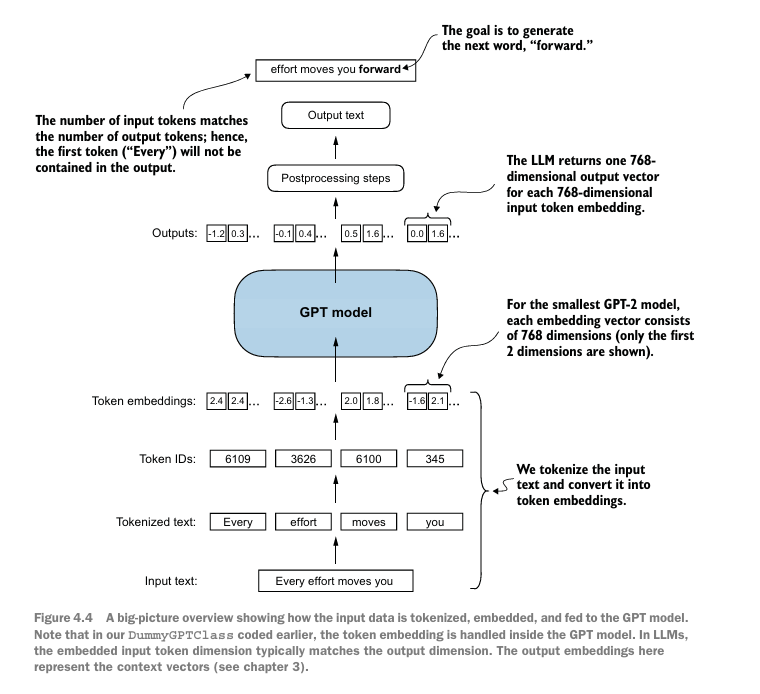

Next,we initialize a new 124 million-parameter DummyGptmodel instance and feed it the tokenized batch

In [5]:
torch.manual_seed(123)
model=DummyGPTModel(GPT_CONFIG_124M)
logits=model(batch)
print("Output shape",logits.shape)
print(logits)


Output shape torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


the output tensor has 2 rows coressponding to the two text sample.
each row has 4 tokens and each tokens is a 50257 dimensional vector

Now that we have taken a top-down look  at the gpt architecture and its inputs and output, we will code the individual placeholders

let us start with the layernoramlization class that will replace the dummy one :)

# 4.2 Normalizing activations with layer normalization

as we know that training nn with many layers can be challenging due to problem like vanishing and exploding gradient descent,it makes harder for the model to update and adjust is weight during training.

now let  us implement the layer normalization which will improve the effieciency and decrease the vanishing and exploding gradient problem

The main idea behind layer normalization is to adjust the activa
tions (outputs) of a neural network layer to have a mean of 0 and a variance of 1, also
known as unit variance. This adjustment speeds up the convergence to effective
weights and ensures consistent, reliable training. In GPT-2 and modern transformer
architectures, layer normalization is typically applied before and after the multi-head
attention module, and, as we have seen with the DummyLayerNorm placeholder, before the final output layer. Figure 4.5 provides a visual overview of how layer normalization
functions.

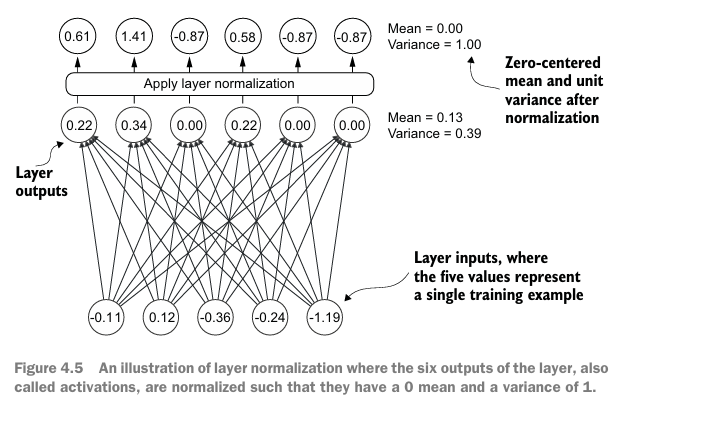

In [6]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps=1e-5
    self.scale=nn.Parameter(torch.ones(emb_dim))
    self.shift=nn.Parameter(torch.zeros(emb_dim))
  def forward(self,x):
    mean=x.mean(dim=-1,keepdim=True)
    var=x.var(dim=-1,keepdim=True,unbiased=False)
    norm_x=(x - mean)/torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

This specific implementation of layer normalization operates on the last dimension of
the input tensor x, which represents the embedding dimension (emb_dim). The vari
able eps is a small constant (epsilon) added to the variance to prevent division by zero
during normalization. The scale and shift are two trainable parameters (of the
same dimension as the input) that the LLM automatically adjusts during training if it
is determined that doing so would improve the model’s performance on its training
task. This allows the model to learn appropriate scaling and shifting that best suit the
data it is processing

lets try the layernorm and apply it to the input

In [7]:
batch_example = torch.randn(2, 5)

In [8]:
In=LayerNorm(emb_dim=5)
out_In=In(batch_example)
mean=out_In.mean(dim=-1,keepdim=True)
var=out_In.var(dim=-1,unbiased=False,keepdim=True)
print("Mean:\n",mean)
print("Variance:\n",var)

Mean:
 tensor([[ 0.0000e+00],
        [-2.3842e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


okay so far we have covered the two of the building blocks,
next we are going to look onto the gelu activaton function used in llms instead of the traditional Relu function we used previously.

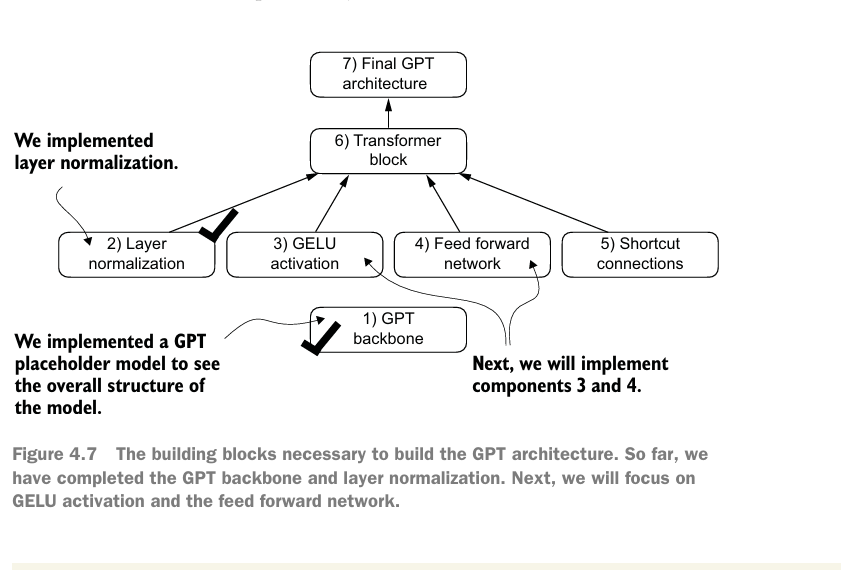

# 4.3 Implementing a feed forward network with GELU activations

it’s common to
implement a computationally cheaper approximation (the original GPT-2 model was
also trained with this approximation, which was found via curve fitting)

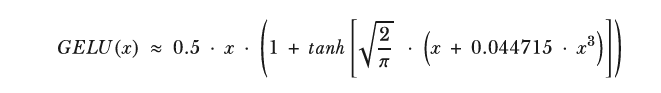

 An implementation of the GELU activation function

In [9]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self,x):
    return 0.5*x*(1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0/torch.pi))*
        (x+0.044715*torch.pow(x,3))
    ))

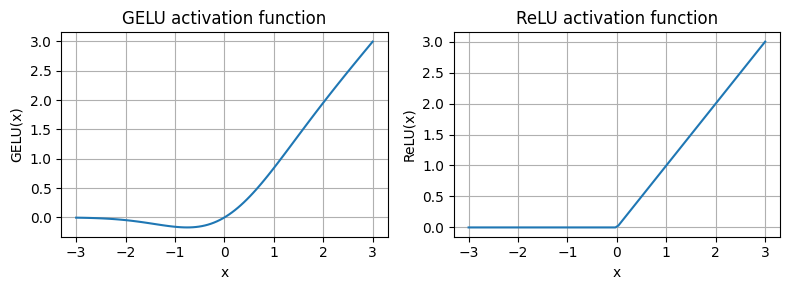

In [10]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

in the graph we can see that the relu is precise linear operation range(0,infinity) where as gelu is non-linear

This characteristic means that
during the training process, neurons that receive negative input can still contribute to
the learning process, albeit to a lesser extent than positive inputs.

next we will implment small neural network which we will be using in the llm's transformer block later

In [11]:
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers = nn.Sequential(
    nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
    GELU(),
    nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),)
  def forward(self, x):
    return self.layers(x)

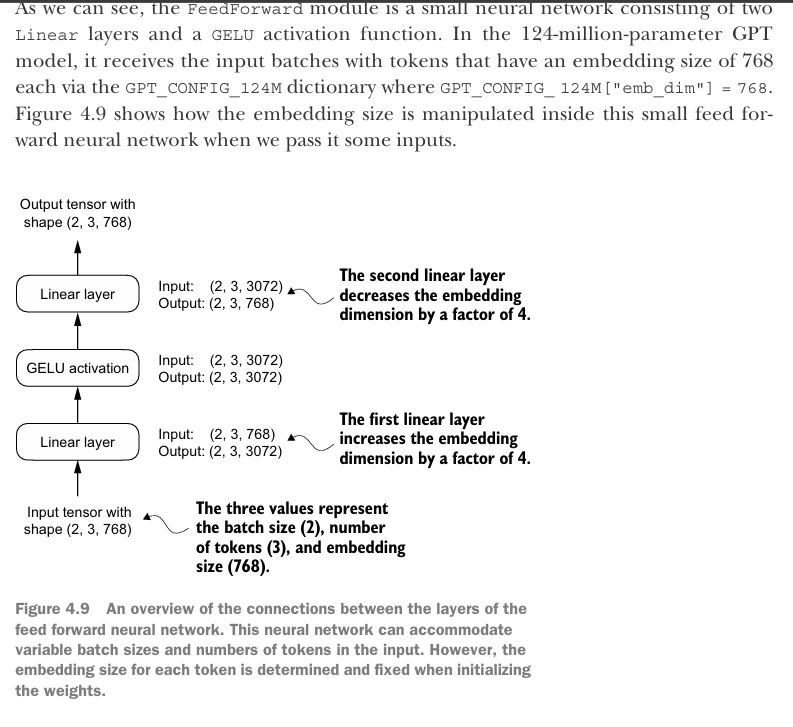

we have implemented most of the llm's building block, now we will
be moving to the shortcut connections

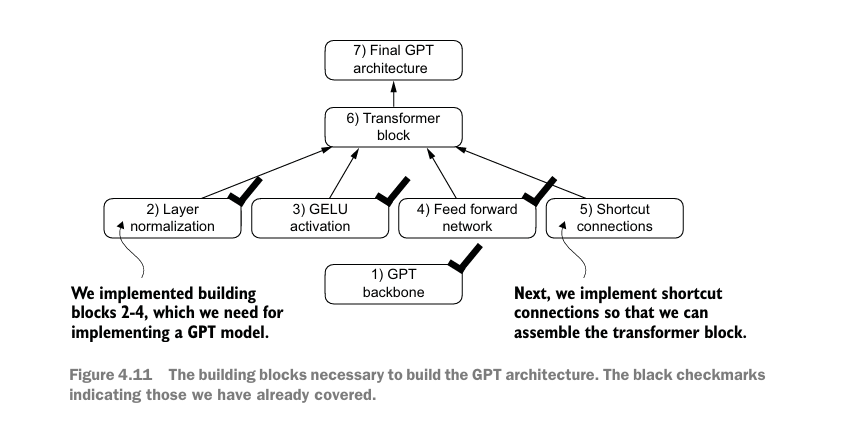

it was basically use on the cv to mitigate the vanishing gradient problem

shortcut connection creates an alternative, shorter path
for the gradient to flow through the network by skipping one or more layers, which is
achieved by adding the output of one layer to the output of a later layer

 This is why
these connections are also known as skip connections. They play a crucial role in pre
serving the flow of gradients during the backward pass in training.


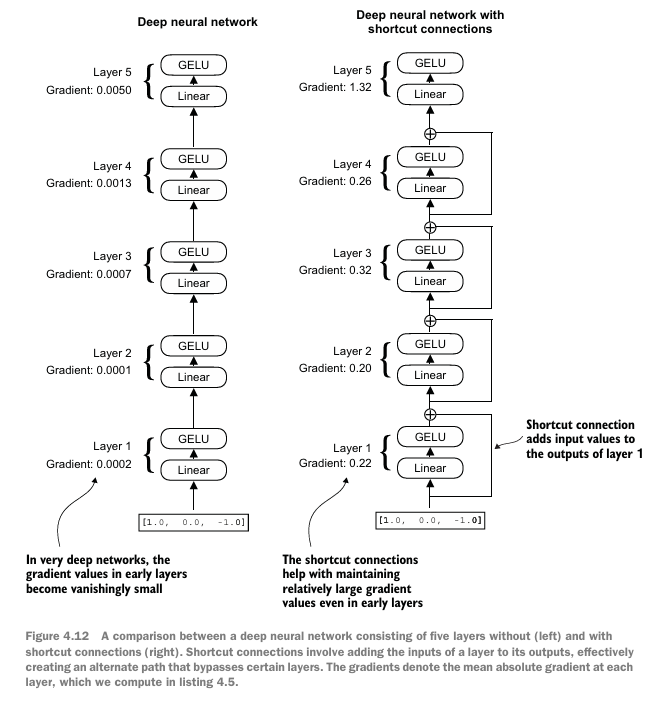

#Connecting attention and linear layers in a transformer block

so now we are going to combine all the concept  and make  them into a transformer block, but let us first  re-create the class multi-head attention class from previous chapter

the transfomer block  consist of multi-head attention,linear layers,the feed forward nn and it also uses droput and shortcut connections

In [12]:
! pip install llms-from-scratch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 kB 461.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 437.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 370.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 679.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 726.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 416.1 kB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


for multiheadattention class we will directly import it from sebastian library

In [13]:
from llms_from_scratch.ch03 import MultiHeadAttention


In [16]:
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"])
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_shortcut=nn.Dropout(cfg["drop_rate"])

  def forward(self,x):
    shortcut=x
    x=self.norm1(x)
    x=self.att(x)
    x=self.drop_shortcut(x)
    x=x+shortcut

    shorcut=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_shortcut(x)
    x=x+shortcut

    return x

Suppose we have 2 input samples with 4 tokens each, where each token is a 768-dimensional embedding vector; then this transformer block applies self-attention, followed by linear layers, to produce an output of similar size

In [17]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


### Coding an GPT model
okay so far we have created all the necessary block and now  let us replace the place holder and make th gpt :)

please note that the transformer block is repeated 12 times in the smallest gpt-2 (124M)

In [30]:
class GPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])

    self.trf_blocks=nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm=LayerNorm(cfg["emb_dim"])
    self.out_head=nn.Linear(
        cfg["emb_dim"],cfg["vocab_size"],bias=False
    )

  def forward(self,in_idx):
    batch_size,seq_len=in_idx.shape
    tok_embeds=self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

In [31]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)

out=model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1410,  0.2043, -0.2649,  ...,  0.1525, -0.1299, -0.2668],
         [-0.0313, -0.5981, -0.6734,  ..., -0.4981,  0.0558, -0.1314],
         [ 0.8531,  0.3315, -0.4281,  ..., -0.1263, -0.8676, -0.0094],
         [-1.2693,  0.9150, -0.2427,  ...,  0.7919,  0.0379, -0.2426]],

        [[-0.4691, -0.3525, -0.0188,  ...,  0.0920, -0.1400, -0.6431],
         [ 0.0524,  0.0654,  0.1765,  ...,  0.8959, -0.4790,  0.3181],
         [ 1.2228,  0.7317, -0.1008,  ...,  0.5494, -0.2042, -0.2386],
         [-0.0551,  0.3294,  0.3401,  ...,  1.1509, -0.6433, -0.0830]]],
       grad_fn=<UnsafeViewBackward0>)


okay so we will train this model in the next chpater ,

lets quickly check if the parameters are 124m aor not

In [32]:
total_params=sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


currenty i am not able to underastand why is that there is an explanation in the booki i am pasting that

Total number of parameters: 163,009,536
As we see above, this model has 163M, not 124M parameters; why?
In the original GPT-2 paper, the researchers applied weight tying, which means that they reused the token embedding layer (tok_emb) as the output layer, which means setting self.out_head.weight = self.tok_emb.weight
The token embedding layer projects the 50,257-dimensional one-hot encoded input tokens to a 768-dimensional embedding representation
The output layer projects 768-dimensional embeddings back into a 50,257-dimensional representation so that we can convert these back into words (more about that in the next section)
So, the embedding and output layer have the same number of weight parameters, as we can see based on the shape of their weight matrices
However, a quick note about its size: we previously referred to it as a 124M parameter model; we can double check this number as follows:

In [33]:
# Calculate the total size in bytes (assuming float32, 4 bytes per parameter)
total_size_bytes = total_params * 4

# Convert to megabytes
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


# Generating text

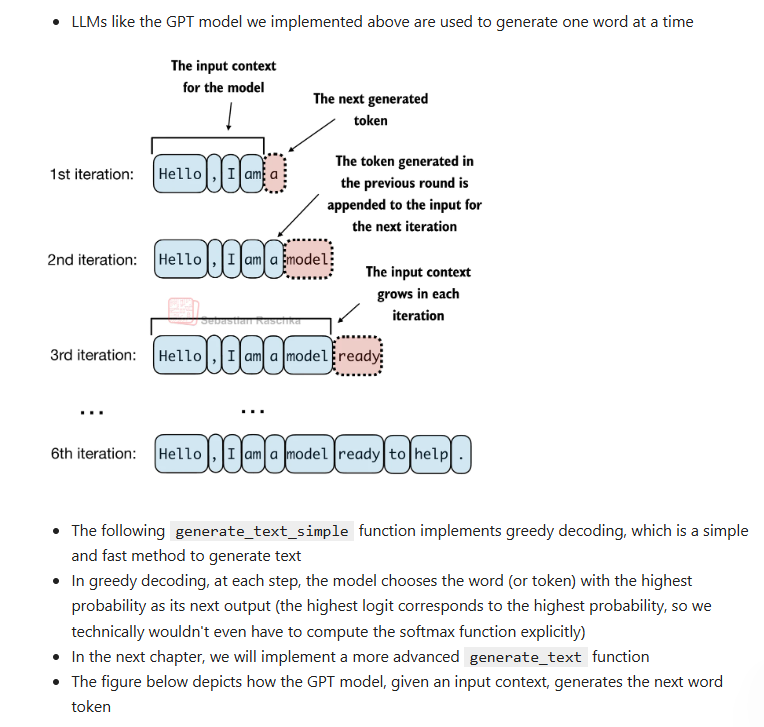

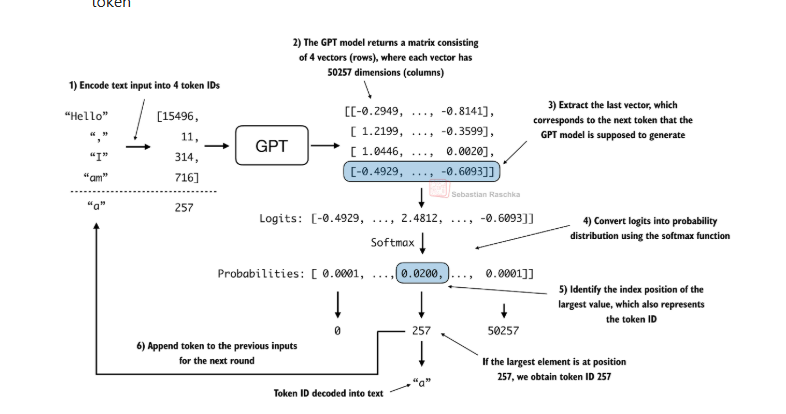

In [34]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [35]:
start_context="Hello,I am"
encoded=tokenizer.encode(start_context)
print("encoded:",encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 40, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [37]:
model.eval() # removing dropout
out=generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]

)

print("Output",out)
print("Output length",len(out[0]))

Output tensor([[15496,    11,    40,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length 10


In [38]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello,I am Featureiman Byeswickattribute argue


well tbh the understanding was pretty low need to revise the chapter again